This notebook take a time-series of Sentinel-2 scene at the specified location for a given year and shows different techniques for creating composites. The notebook shows how to creat Median and Percentile composites and see its effect in removing effect of clouds.

### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray \
        dask['distributed'] jupyter-server-proxy xrscipy odc-algo

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
import xrscipy.signal as xrs
from odc.algo import xr_quantile
from odc.stac import configure_s3_access, load

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Get Satellite Imagery using STAC API

We define a location and time of interest to get some satellite imagery.

In [ ]:
latitude = 27.163
longitude = 82.608
year = 2023

Let's use Element84 search endpoint to look for items from the sentinel-2-l2a collection on AWS and load the matching images as a XArray Dataset.

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        's2:nodata_pixel_percentage': {'lt': 10}
    }

)
items = search.item_collection()

# Load to XArray
ds = load(
    items,
    bands=['red', 'green', 'blue', 'scl'],
    resolution=100,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)
ds

### Processing Data

We have a data cube of multiple scenes collected through the year. As XArray supports vectorized operations, we can work with the entire DataSet the same way we would process a single scene.

The Sentinel-2 scenes come with NoData value of 0. So we set the correct NoData value before further processing.

In [ ]:
# Mask nodata values
ds = ds.where(ds != 0)

Apply scale and offset to all spectral bands

In [ ]:
# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in ds.data_vars if band != 'scl']
for band in data_bands:
  ds[band] = ds[band] * scale + offset

Check the size of the data cube.



In [ ]:
print(f'Data cube size: {ds.nbytes/1e6:.2f} MB.')

Let’s call compute() to kick-off the dask graph and load the results into memory.

In [ ]:
%%time
ds = ds.compute()

### Preview Individual Scenes

Render each scene as a PNG with the acquisition date labeled at the bottom.

In [ ]:
for i in range(ds.sizes['time']):
    scene = ds.isel(time=i)
    date_str = scene.time.dt.strftime('%Y-%m-%d').item()

    rgb_da = scene[['red', 'green', 'blue']].to_array('band')
  
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(6, 6)
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title('')
    fig.text(0.5, 0.05, date_str, ha='center', fontsize=12)
    output_filename = f'{date_str}.png'
    output_filepath = os.path.join(output_folder, output_filename)
    fig.savefig(output_filepath, bbox_inches='tight')
    plt.close(fig)

    print(f'Wrote {output_filepath}')
    

### Creating Composites

Instead of working with individual scenes that maybe contaminated to clouds and cloud shadows - we can create a *composite* image from multiple scenes by picking the best available pixel that is representative of the chosen period. Typically, for optical sensors - this will be the **median** value from the stack of available images.

We first apply a cloud-mask to set known cloudy pixels to nodata.

In [ ]:
ds = ds[data_bands].where(~ds.scl.isin([3,8,9,10]))
ds

#### Monthly Composites

We can aggregate the time-series to a monthly median composites `groupby()` method.

In [ ]:
monthly = ds.groupby('time.month').median(dim='time')
monthly

Preview all monthly composites together in a 3x4 grid.

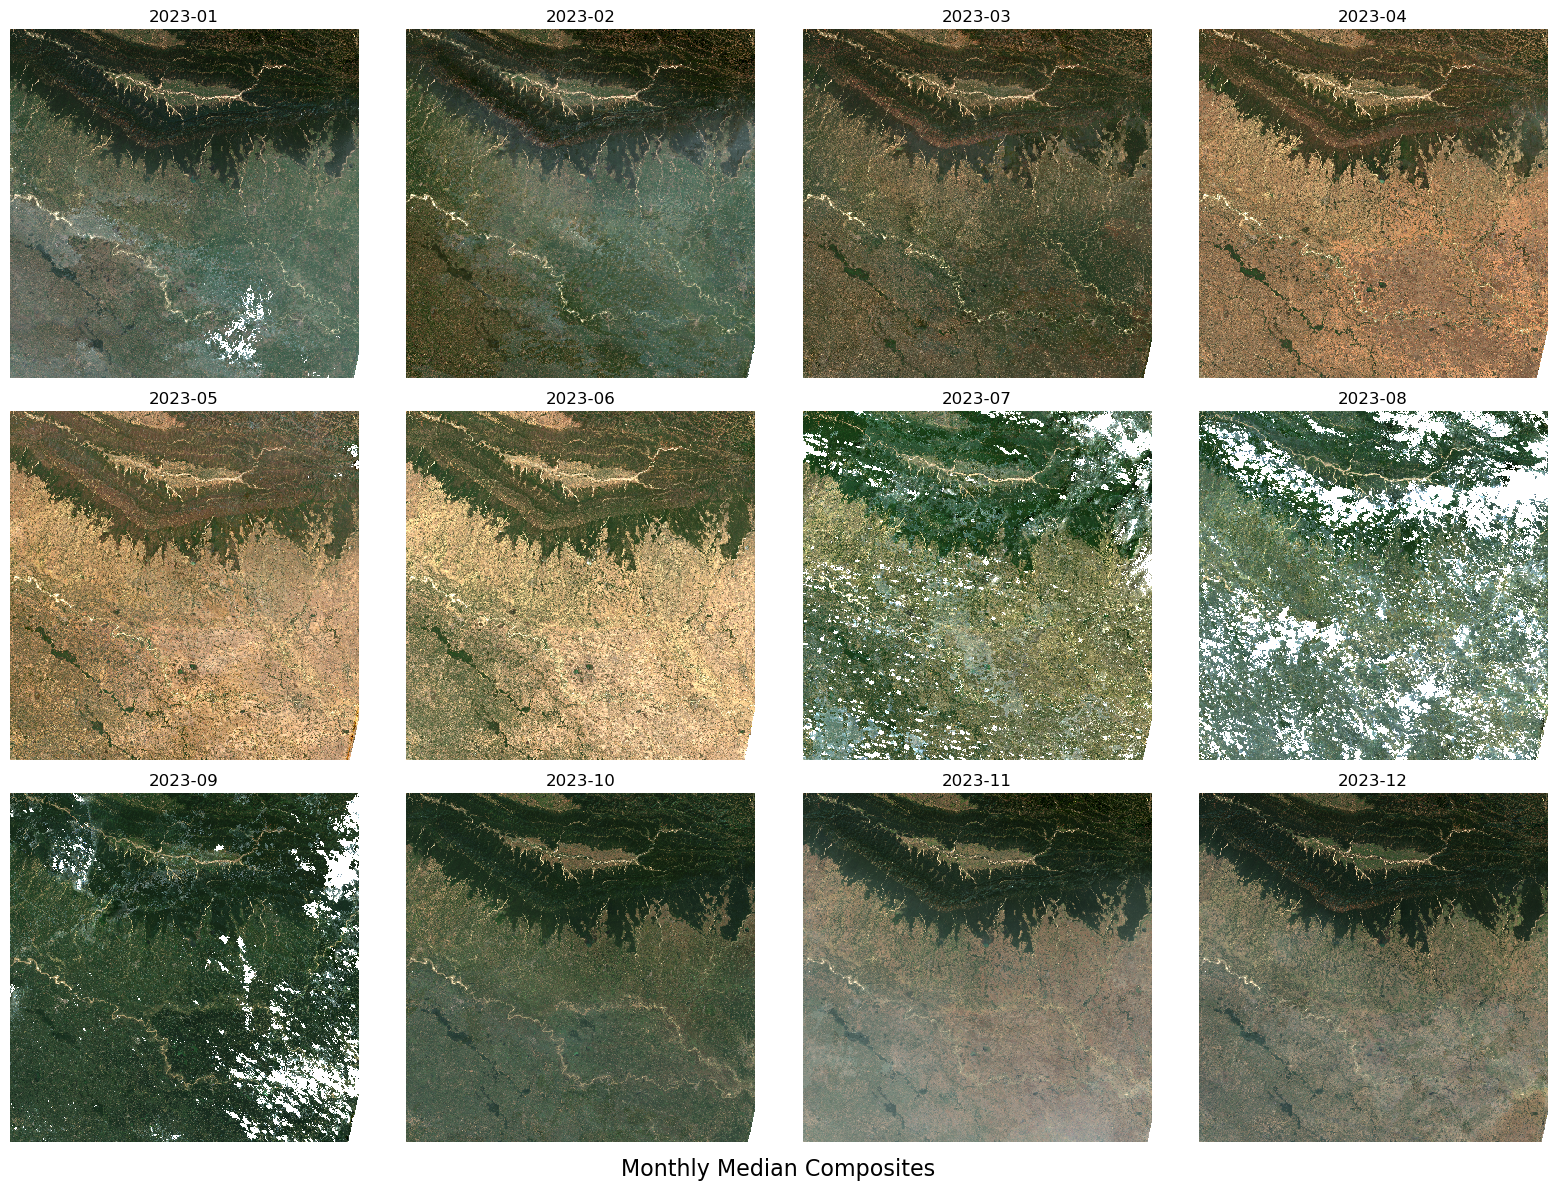

In [35]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):
    scene = monthly.isel(month=i)
    date_str = f'{year}-{scene.month.item():02d}'

    rgb_da = scene[['red', 'green', 'blue']].to_array('band')
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title(date_str)

    fig.canvas.draw()
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    output_filepath = os.path.join(output_folder, f'preview_{date_str}.png')
    fig.savefig(output_filepath, bbox_inches=extent)

plt.suptitle('Monthly Median Composites', fontsize=16, y=0)
plt.tight_layout()
plt.show()

#### Annual Composites

We can get an annual median composite by aggregating all the scenes using `.median()`. This gives the 50th-percentile value at each pixel. For very cloudy regions, you can also create a different percentile composite using `odc.algo.xr_quantile()` to get a cloud-free mosaic.

Preview all percentile composites together in a 2x2 grid.

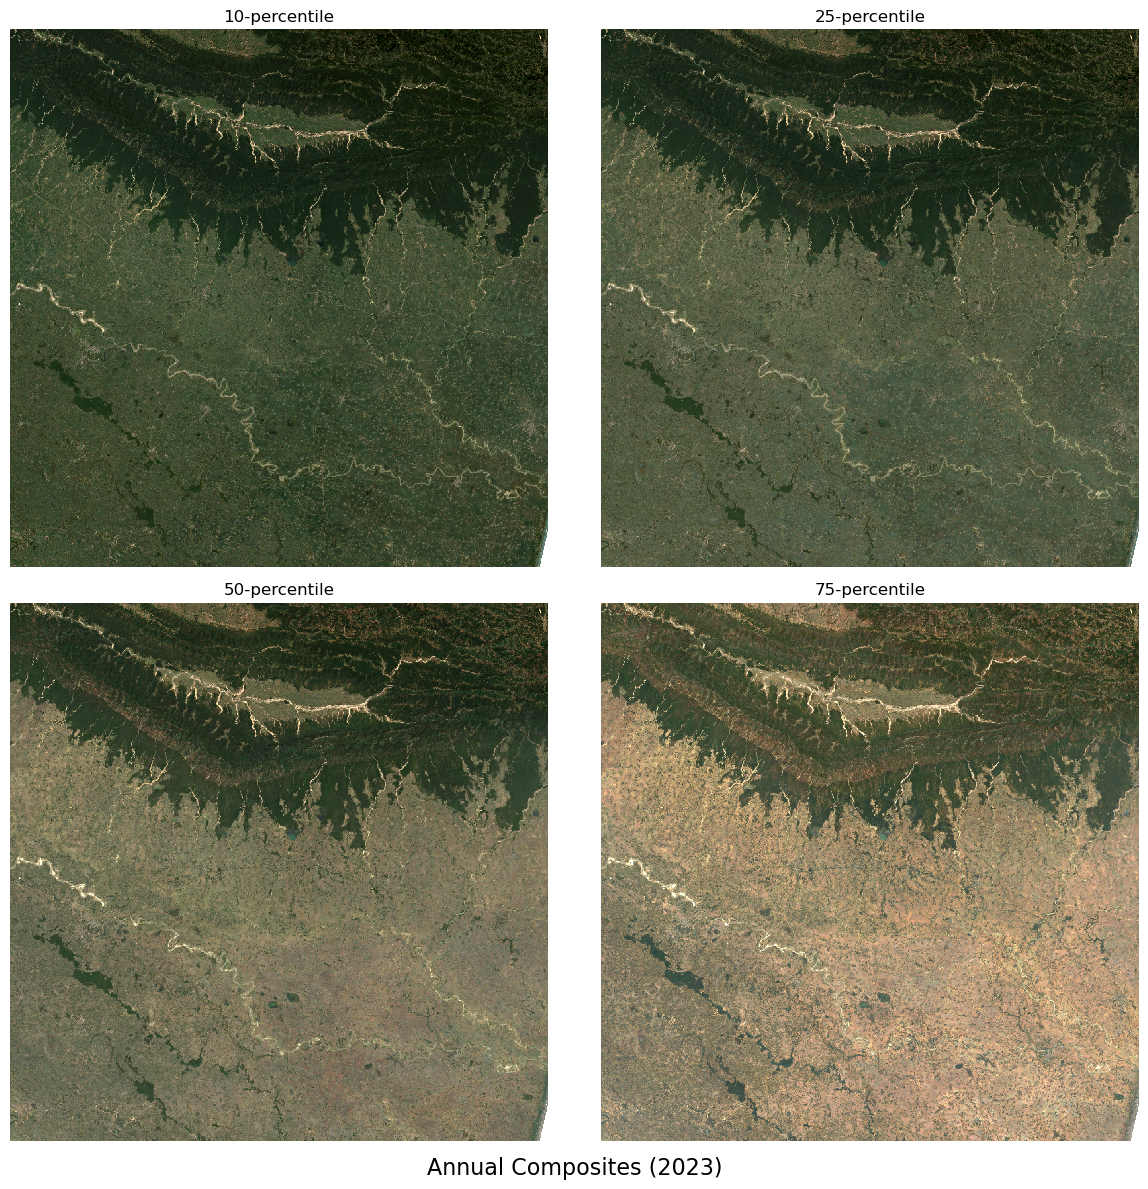

In [34]:
percentiles = [0.1, 0.25, 0.5, 0.75]
annual_percentiles = xr_quantile(ds, percentiles, nodata=np.nan)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for p, ax in zip(percentiles, axes.flat):
    label = f'{int(p * 100)}-percentile'

    rgb_da = annual_percentiles.sel(quantile=p)[['red', 'green', 'blue']].to_array('band')
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title(label)

    fig.canvas.draw()
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    output_filepath = os.path.join(output_folder, f'preview_annual_composite_{year}_{label}.png')
    fig.savefig(output_filepath, bbox_inches=extent)

plt.suptitle(f'Annual Composites ({year})', fontsize=16, y=0)
plt.tight_layout()
plt.show()

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()